# Базовый блок. Обработка текстов с помощью нейронных сетей. ДЗ Ultra Pro

## Классификация 20 русских писателей

**Формат данных:** один файл на писателя — `Фамилия.txt`

**Цели:**
- Bag of Words: точность **≥ 95%**
- Embedding: точность **75-80%**

**Особенности задания:**
- Балансировка классов
- **Цикл** для разбивки на train/test
- Проверочная выборка — **20%** от общей

## Импорт библиотек

In [ ]:
import numpy as np
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import gdown
import os
import time
import re
import matplotlib.pyplot as plt

%matplotlib inline

## Загрузка данных

In [ ]:
# Скачиваем базу 20 писателей
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip', None, quiet=True)

'20writers.zip'

In [ ]:
# Распаковка архива
!unzip -qo 20writers.zip -d 20writers/

FILE_DIR = '20writers'
files = sorted(os.listdir(FILE_DIR))
print(f'Всего файлов: {len(files)}')
print('Файлы:')
for f in files:
    print(f'  {f}')

Всего файлов: 20
Файлы:
  Беляев.txt
  Булгаков.txt
  Васильев.txt
  Гоголь.txt
  Гончаров.txt
  Горький.txt
  Грибоедов.txt
  Достоевский.txt
  Каверин.txt
  Катаев.txt
  Куприн.txt
  Лермонтов.txt
  Лесков.txt
  Носов.txt
  Пастернак.txt
  Пушкин.txt
  Толстой.txt
  Тургенев.txt
  Чехов.txt
  Шолохов.txt


## Загрузка текстов

Каждый файл — это один писатель. Имя писателя извлекаем из имени файла, убирая расширение `.txt`.

In [ ]:
CLASS_LIST = []          # Имена писателей
text_all = []            # Тексты по классам

for file_name in sorted(os.listdir(FILE_DIR)):
    # Имя писателя = имя файла без .txt
    class_name = file_name.replace('.txt', '')

    # Читаем файл
    with open(f'{FILE_DIR}/{file_name}', 'r', encoding='utf-8') as f:
        text = f.read().replace('\n', ' ')

    CLASS_LIST.append(class_name)
    text_all.append(text)

    print(f'  {class_name:<25}: {len(text)} символов')

CLASS_COUNT = len(CLASS_LIST)
print(f'\nВсего классов: {CLASS_COUNT}')

  Беляев                   : 2255254 символов
  Булгаков                 : 2001064 символов
  Васильев                 : 2952792 символов
  Гоголь                   : 1965119 символов
  Гончаров                 : 3104712 символов
  Горький                  : 2523380 символов
  Грибоедов                : 969109 символов
  Достоевский              : 5178950 символов
  Каверин                  : 1992830 символов
  Катаев                   : 2579246 символов
  Куприн                   : 2328900 символов
  Лермонтов                : 1972541 символов
  Лесков                   : 2152214 символов
  Носов                    : 2399413 символов
  Пастернак                : 3089426 символов
  Пушкин                   : 3408339 символов
  Толстой                  : 3357061 символов
  Тургенев                 : 1980206 символов
  Чехов                    : 6611627 символов
  Шолохов                  : 3386268 символов

Всего классов: 20


## Балансировка классов

Объёмы текстов у разных писателей сильно отличаются. Чтобы у всех классов было примерно одинаковое количество примеров — обрезаем все тексты до длины самого короткого.

In [ ]:
# Минимальная длина среди всех текстов
min_len = min(len(t) for t in text_all)
print(f'Минимальная длина: {min_len} символов')

# Балансируем — обрезаем все тексты
text_balanced = [t[:min_len] for t in text_all]

print('\nПосле балансировки все тексты по {} символов'.format(min_len))

Минимальная длина: 969109 символов

После балансировки все тексты по 969109 символов


## Деление на обучающую (80%) и тестовую (20%) выборки через цикл

По требованию задания — применяем **цикл** для разбивки.

In [ ]:
TEST_SHARE = 0.2  # 20% на проверочную

text_train = []
text_test = []

# Цикл по всем классам
for cls in range(CLASS_COUNT):
    text = text_balanced[cls]

    # Граница: 80% — обучение, 20% — тест
    train_len = int(len(text) * (1 - TEST_SHARE))

    text_train.append(text[:train_len])
    text_test.append(text[train_len:])

print(f'Обучающая выборка на класс: {len(text_train[0])} символов ({(1-TEST_SHARE)*100:.0f}%)')
print(f'Тестовая выборка на класс: {len(text_test[0])} символов ({TEST_SHARE*100:.0f}%)')

Обучающая выборка на класс: 775287 символов (80%)
Тестовая выборка на класс: 193822 символов (20%)


## Параметры преобразования

In [ ]:
VOCAB_SIZE = 20000   # Объём словаря (увеличен для 20 классов)
WIN_SIZE   = 1000    # Длина окна в словах
WIN_HOP    = 100     # Шаг окна (плотная нарезка)

## Токенизация

In [ ]:
class timex:
    def __enter__(self):
        self.t = time.time()
        return self
    def __exit__(self, type, value, traceback):
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

In [ ]:
# Создание токенизатора и обучение на тренировочных текстах
with timex():
    tokenizer = Tokenizer(num_words=VOCAB_SIZE,
                          filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ',
                          oov_token='неизвестное_слово',
                          char_level=False)
    tokenizer.fit_on_texts(text_train)

print(f'Размер словаря: {len(tokenizer.word_index)}')

Время обработки: 6.18 с
Размер словаря: 185786


In [ ]:
# Преобразование в последовательности индексов
with timex():
    seq_train = tokenizer.texts_to_sequences(text_train)
    seq_test = tokenizer.texts_to_sequences(text_test)

print('Длины последовательностей (обучающие):')
for cls in range(CLASS_COUNT):
    print(f'  {CLASS_LIST[cls]:<25}: {len(seq_train[cls]):>8} токенов')

Время обработки: 4.21 с
Длины последовательностей (обучающие):
  Беляев                   :   116009 токенов
  Булгаков                 :   116731 токенов
  Васильев                 :   117965 токенов
  Гоголь                   :   118315 токенов
  Гончаров                 :   124127 токенов
  Горький                  :   127082 токенов
  Грибоедов                :   123210 токенов
  Достоевский              :   117922 токенов
  Каверин                  :   119103 токенов
  Катаев                   :   115814 токенов
  Куприн                   :   117412 токенов
  Лермонтов                :   121526 токенов
  Лесков                   :   125223 токенов
  Носов                    :   118651 токенов
  Пастернак                :   113345 токенов
  Пушкин                   :   118239 токенов
  Толстой                  :   118616 токенов
  Тургенев                 :   119918 токенов
  Чехов                    :   120706 токенов
  Шолохов                  :   115856 токенов


## Формирование выборок методом скользящего окна

In [ ]:
def split_sequence(sequence, win_size, hop):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]

def vectorize_sequence(seq_list, win_size, hop):
    class_count = len(seq_list)
    x, y = [], []
    for cls in range(class_count):
        vectors = split_sequence(seq_list[cls], win_size, hop)
        x += vectors
        y += [utils.to_categorical(cls, class_count)] * len(vectors)
    return np.array(x), np.array(y)

In [ ]:
with timex():
    x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
    x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

print(f'Обучающая выборка: {x_train.shape}')
print(f'Тестовая выборка: {x_test.shape}')

print('\nКоличество окон по классам в обучающей выборке:')
y_labels = np.argmax(y_train, axis=1)
for cls in range(CLASS_COUNT):
    count = np.sum(y_labels == cls)
    print(f'  {CLASS_LIST[cls]:<25}: {count} окон')

Время обработки: 2.43 с
Обучающая выборка: (23672, 1000)
Тестовая выборка: (5766, 1000)

Количество окон по классам в обучающей выборке:
  Беляев                   : 1151 окон
  Булгаков                 : 1158 окон
  Васильев                 : 1170 окон
  Гоголь                   : 1174 окон
  Гончаров                 : 1232 окон
  Горький                  : 1261 окон
  Грибоедов                : 1223 окон
  Достоевский              : 1170 окон
  Каверин                  : 1182 окон
  Катаев                   : 1149 окон
  Куприн                   : 1165 окон
  Лермонтов                : 1206 окон
  Лесков                   : 1243 окон
  Носов                    : 1177 окон
  Пастернак                : 1124 окон
  Пушкин                   : 1173 окон
  Толстой                  : 1177 окон
  Тургенев                 : 1190 окон
  Чехов                    : 1198 окон
  Шолохов                  : 1149 окон


## Bag of Words матрицы

In [ ]:
with timex():
    x_train_01 = tokenizer.sequences_to_matrix(x_train.tolist())
    x_test_01 = tokenizer.sequences_to_matrix(x_test.tolist())

print(f'BoW обучающая: {x_train_01.shape}')
print(f'BoW тестовая: {x_test_01.shape}')

Время обработки: 12.58 с
BoW обучающая: (23672, 20000)
BoW тестовая: (5766, 20000)


## Сервисные функции

In [ ]:
def compile_train_model(model, x_train, y_train, x_val, y_val,
                        epochs=30, batch_size=128, figsize=(20, 5)):
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()

    history = model.fit(x_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График обучения')
    ax1.plot(history.history['accuracy'], label='Обучающая')
    ax1.plot(history.history['val_accuracy'], label='Проверочная')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Точность')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Обучающая')
    ax2.plot(history.history['val_loss'], label='Проверочная')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


def eval_model(model, x, y_true, class_labels=[], title='', figsize=(15, 15)):
    y_pred = model.predict(x)
    cm = confusion_matrix(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1), normalize='true')
    cm = np.around(cm, 3)

    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()
    plt.title(f'{title}: матрица ошибок', fontsize=16)
    fig.autofmt_xdate(rotation=45)
    plt.show()

    accuracy = 100. * cm.diagonal().mean()
    correct = sum(1 for cls in range(len(class_labels)) if np.argmax(cm[cls]) == cls)
    print(f'\nВерно распознано классов: {correct}/{len(class_labels)}')
    print(f'Средняя точность: {accuracy:.1f}%')
    return accuracy


def compile_train_eval(model, x_train, y_train, x_test, y_test, title='', epochs=20):
    compile_train_model(model, x_train, y_train, x_test, y_test, epochs=epochs)
    return eval_model(model, x_test, y_test, class_labels=CLASS_LIST, title=title)

# Модель 1: Bag of Words (цель > 95%)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 400)            │     8,000,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         4,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,087,020 (30.85 MB)

 Trainable params: 8,085,820 (30.84 MB)

 Non-trainable params: 1,200 (4.69 KB)

Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9511 - loss: 0.2224 - val_accuracy: 0.8852 - val_loss: 0.5584
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.8916 - val_loss: 0.4220
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8965 - val_loss: 0.3869
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8966 - val_loss: 0.3759
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 9.6005e-04 - val_accuracy: 0.8996 - val_loss: 0.3570
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 6.6557e-04 - val_accuracy: 0.8994 - val_loss: 0.3534
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 4.7552e-04 - val_accuracy: 0.8998 - val_loss: 0.3490
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 3.86

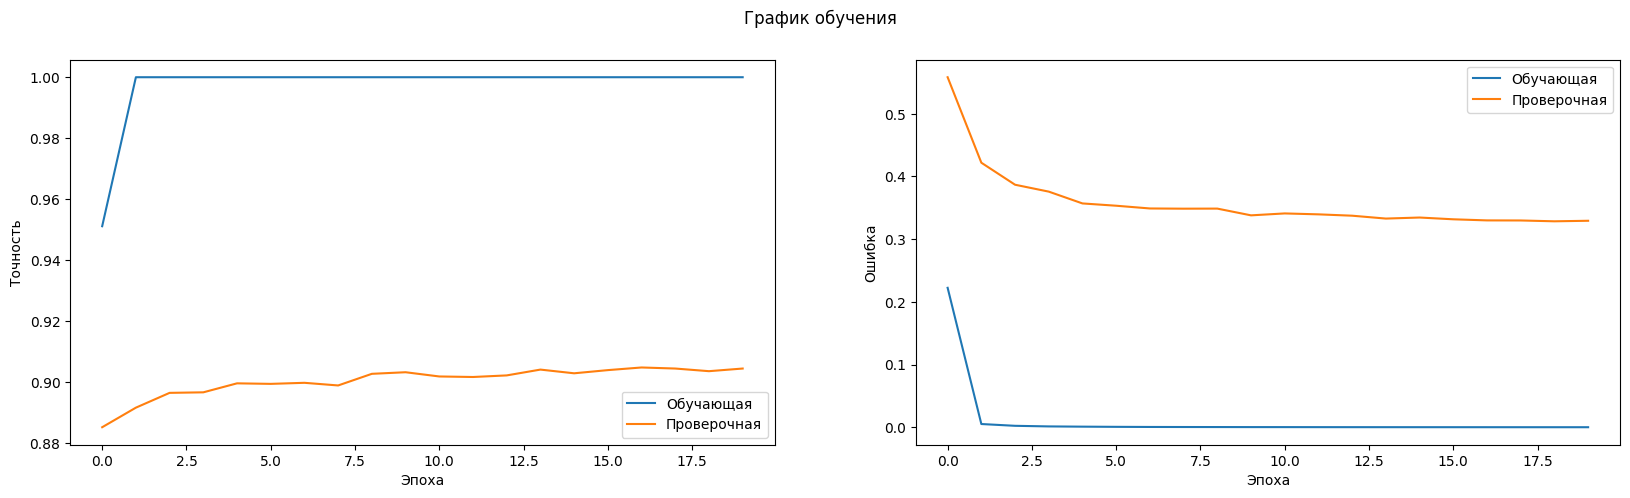

181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


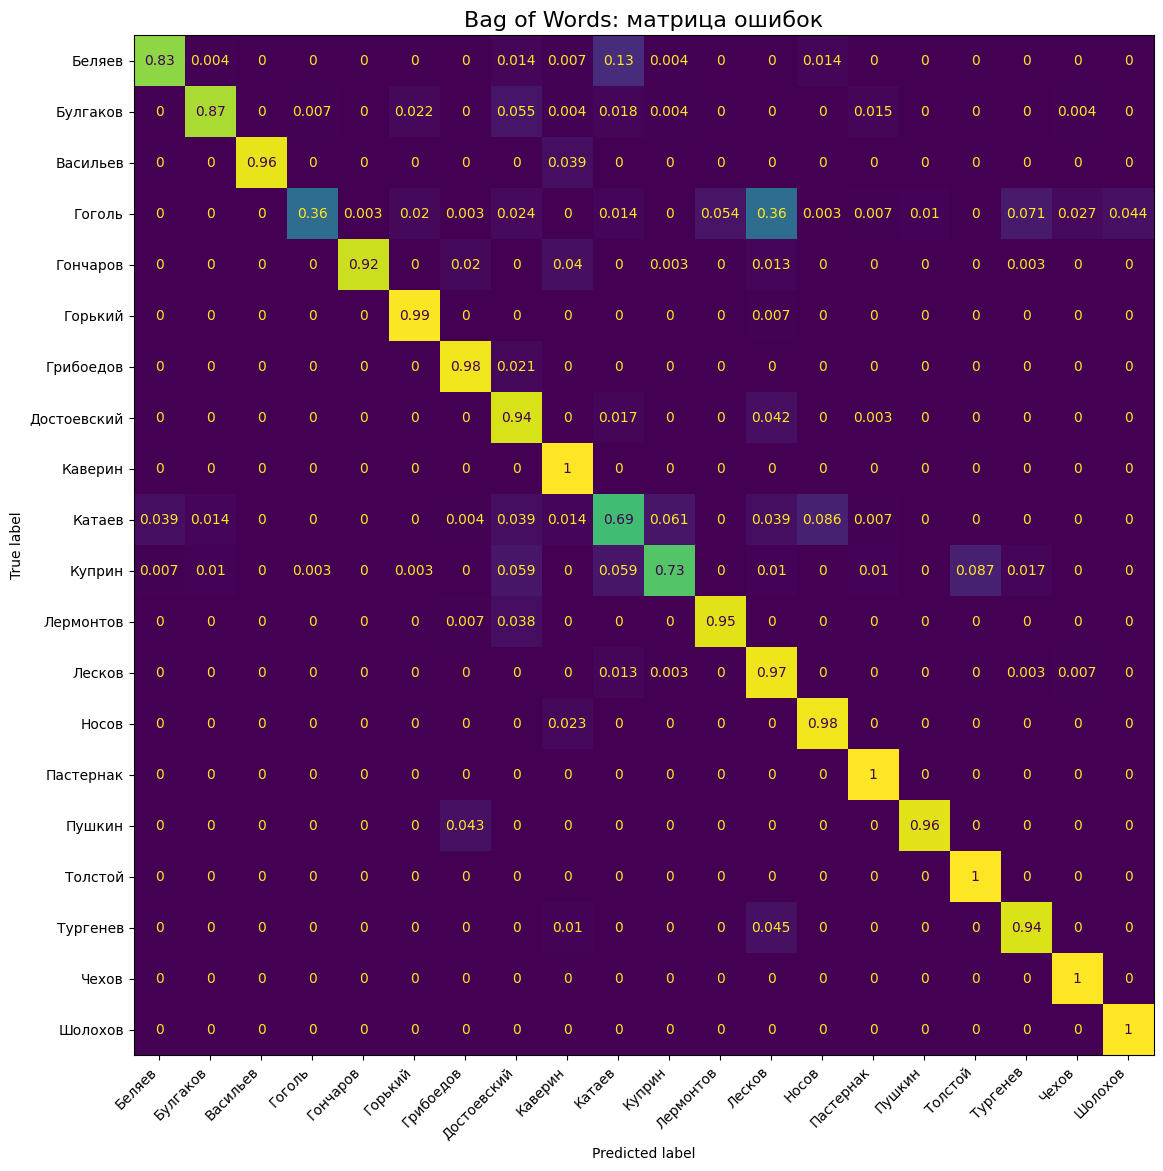


Верно распознано классов: 20/20
Средняя точность: 90.4%


In [ ]:
model_bow = Sequential()
model_bow.add(Dense(400, input_dim=VOCAB_SIZE, activation='relu'))
model_bow.add(Dropout(0.4))
model_bow.add(BatchNormalization())
model_bow.add(Dense(200, activation='relu'))
model_bow.add(Dropout(0.3))
model_bow.add(BatchNormalization())
model_bow.add(Dense(CLASS_COUNT, activation='softmax'))

acc_bow = compile_train_eval(model_bow, x_train_01, y_train, x_test_01, y_test,
                              title='Bag of Words', epochs=20)

# Модель 2: Embedding + Flatten (цель 75-80%)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.6836 - loss: 1.2173 - val_accuracy: 0.4348 - val_loss: 2.3345
Epoch 2/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9998 - loss: 0.0254 - val_accuracy: 0.7126 - val_loss: 1.8342
Epoch 3/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.7180 - val_loss: 1.2403
Epoch 4/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.7284 - val_loss: 1.0082
Epoch 5/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.7336 - val_loss: 0.9477
Epoch 6/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.7320 - val_loss: 0.9405
Epoch 7/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.7378 - val_loss: 0.9177
Epoch 8/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 1.0000 - loss: 0.0011 - val_acc

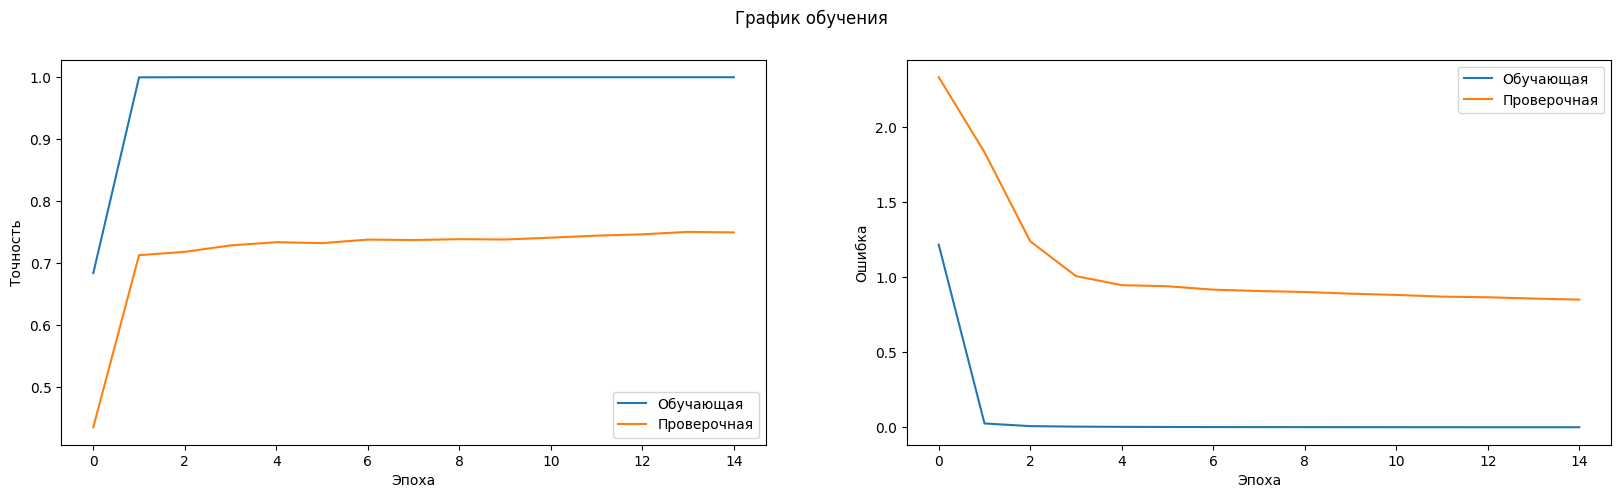

181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


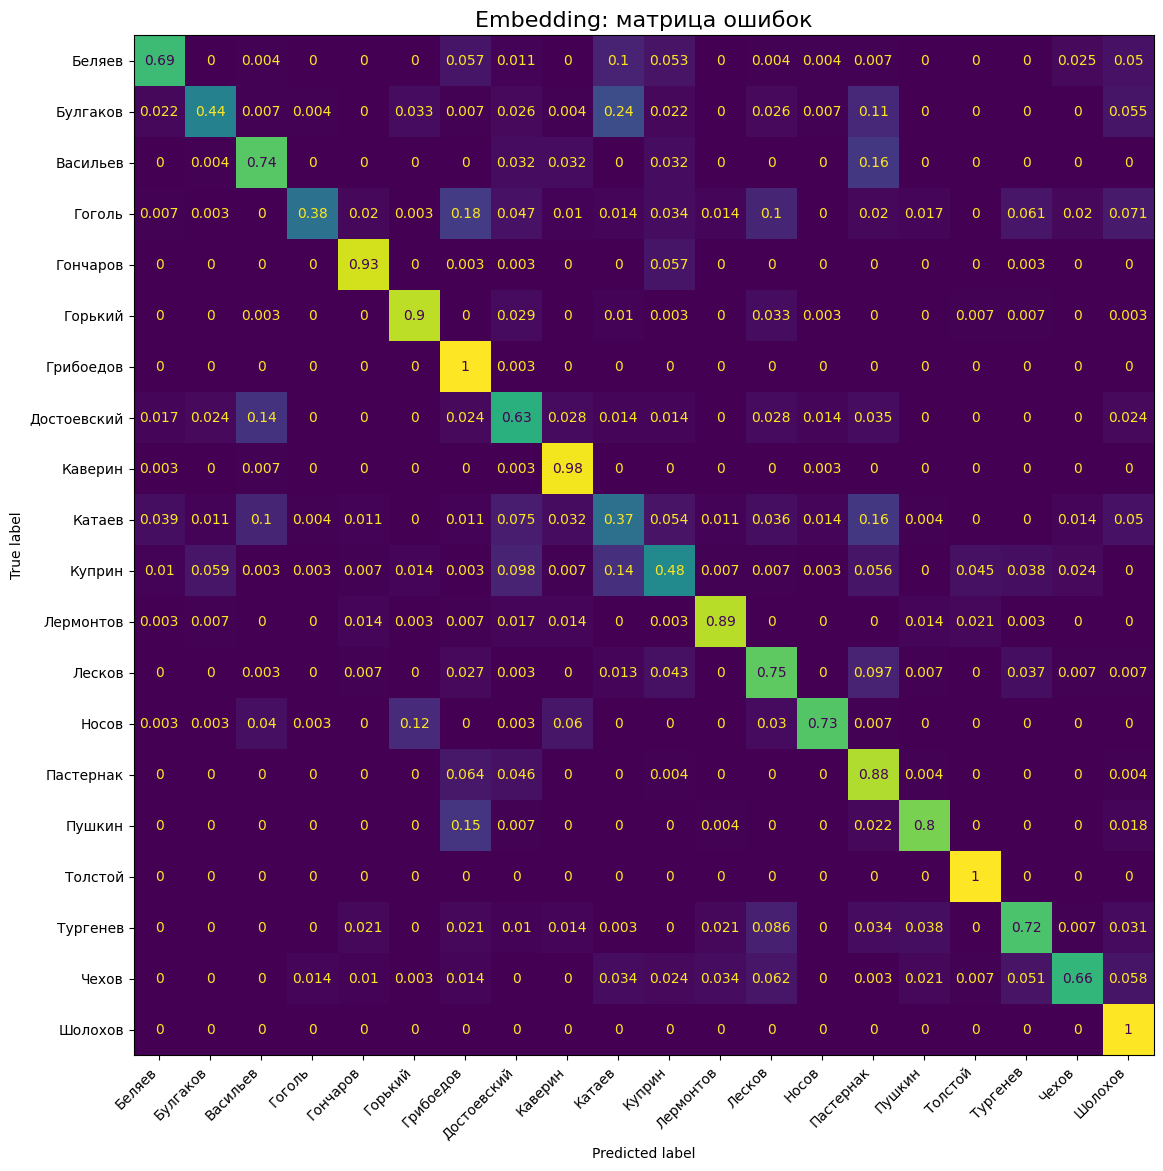


Верно распознано классов: 20/20
Средняя точность: 74.8%


In [ ]:
model_emb = Sequential()
model_emb.add(Embedding(input_dim=VOCAB_SIZE, output_dim=200, input_length=WIN_SIZE))
model_emb.add(SpatialDropout1D(0.3))
model_emb.add(Flatten())
model_emb.add(BatchNormalization())
model_emb.add(Dense(200, activation='relu'))
model_emb.add(Dropout(0.3))
model_emb.add(BatchNormalization())
model_emb.add(Dense(CLASS_COUNT, activation='softmax'))

acc_emb = compile_train_eval(model_emb, x_train, y_train, x_test, y_test,
                              title='Embedding', epochs=15)

# Итоги

In [ ]:
print('РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ 20 ПИСАТЕЛЕЙ')
print(f'Bag of Words: {acc_bow:.1f}%  (цель ≥ 95%)')

if acc_bow >= 95:
    print('BoW: цель достигнута')
else:
    print('BoW: не вышло')

if 75 <= acc_emb <= 85:
    print('Embedding: цель достигнута')
else:
    print(f'Embedding: точность {acc_emb:.1f}%')

РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ 20 ПИСАТЕЛЕЙ
Bag of Words: 90.4%  (цель ≥ 95%)
BoW: не вышло
Embedding: точность 74.8%


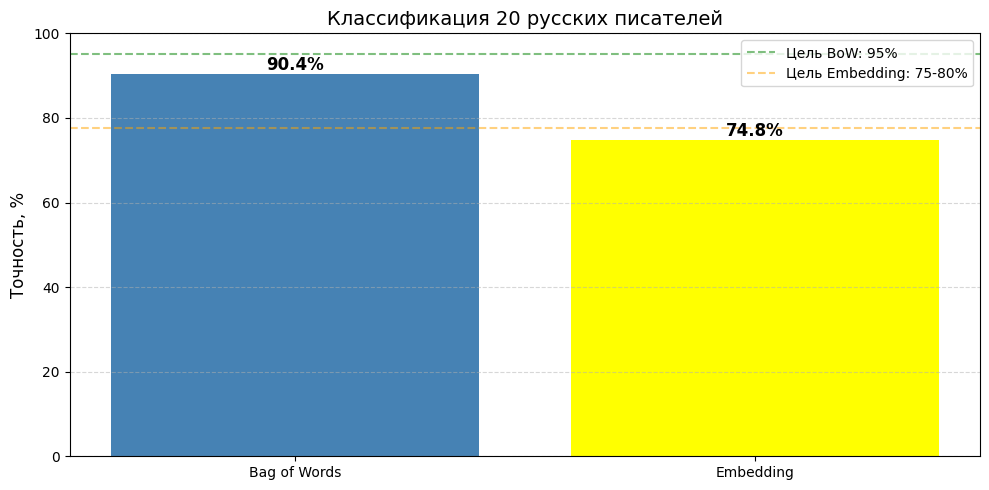

In [ ]:
# Сравнительная диаграмма
fig, ax = plt.subplots(figsize=(10, 5))
names = ['Bag of Words', 'Embedding']
values = [acc_bow, acc_emb]

bars = ax.bar(names, values, color=['steelblue', 'yellow'])
ax.set_ylabel('Точность, %', fontsize=12)
ax.set_title('Классификация 20 русских писателей', fontsize=14)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Целевые линии
ax.axhline(y=95, color='green', linestyle='--', alpha=0.5, label='Цель BoW: 95%')
ax.axhline(y=77.5, color='orange', linestyle='--', alpha=0.5, label='Цель Embedding: 75-80%')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()